# 12 Pathway Enrichment

**Q1:** Are gene signatures tissue-derived or shared across tissues?  
**Q2:** Do pathologies in the same tissue share gene signatures?

**Approach:** GSEA prerank on **all 20K genes** ranked by importance (from NB11).  
Three gene set libraries tested separately: KEGG 2026, Reactome 2024, GO BP 2025.

**Structure:** Liver | cirrhosis first as proof of concept, then scale to all 9 pairs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
from scipy.stats import spearmanr

from gtex_biomarkers.config import Config

Config.ensure_dirs()

# Load full 20K gene rankings from NB11
full_imp = pd.read_csv(Config.TABLES_DIR / "pc_gene_importance_full.csv")
pairs = full_imp.groupby(["tissue", "category"]).ngroups
print(f"Loaded {len(full_imp)} rows — {pairs} pairs x {len(full_imp)//pairs:,} genes")

Loaded 180000 rows — 9 pairs x 20,000 genes


In [2]:
FDR_CUTOFF = 0.05
TOP_N_PLOT = 20

def build_ranked_list(grp):
    """Convert a group from full_imp to a GSEA-ready ranked Series."""
    ranked = grp[["gene_name", "importance"]].copy()
    ranked = ranked[~ranked["gene_name"].str.startswith("ENSG")]
    ranked["gene_name"] = ranked["gene_name"].str.upper()
    ranked = ranked.drop_duplicates(subset="gene_name")
    ranked = ranked.set_index("gene_name")["importance"]
    return ranked.sort_values(ascending=False)


def run_gsea_one_lib(ranked, lib_name, tag=""):
    """Run GSEA prerank for a single gene set library. Returns results DataFrame."""
    pre = gp.prerank(
        rnk=ranked,
        gene_sets=lib_name,
        min_size=10,
        max_size=500,
        permutation_num=1000,
        outdir=None,
        seed=42,
        no_plot=True,
        verbose=False,
    )
    res = pre.res2d.copy()
    for col in ["ES", "NES", "NOM p-val", "FDR q-val", "FWER p-val"]:
        if col in res.columns:
            res[col] = pd.to_numeric(res[col], errors="coerce")
    return res


def plot_top_pathways(res, tag, lib_label, top_n=TOP_N_PLOT):
    """Bar chart of top positive-NES pathways."""
    sig = res[(res["FDR q-val"] < FDR_CUTOFF) & (res["NES"] > 0)].copy()
    if sig.empty:
        print(f"  {lib_label}: no significant positive NES pathways")
        return
    plot_df = sig.nlargest(min(top_n, len(sig)), "NES").copy()
    # Strip library prefix from term names for cleaner labels
    plot_df["label"] = plot_df["Term"].str.replace(f"{lib_label}__", "", regex=False).str[:55]
    plot_df = plot_df.sort_values("NES")

    fig, ax = plt.subplots(figsize=(8, max(4, len(plot_df) * 0.35)))
    ax.barh(range(len(plot_df)), plot_df["NES"].values, color="#4878A8", height=0.7)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df["label"].values, fontsize=7)
    ax.set_xlabel("NES")
    ax.set_title(f"{tag} — {lib_label} (top {len(plot_df)})", fontsize=10)
    fig.tight_layout()
    plt.show()

---
## 12.1 — Proof of Concept: Liver | Cirrhosis

Run GSEA prerank (all 20K genes) for each library separately.

In [3]:
GENE_SET_LIBS = ["KEGG_2026", "Reactome_Pathways_2024", "GO_Biological_Process_2025"]

demo_grp = full_imp[(full_imp["tissue"] == "Liver") & (full_imp["category"] == "cirrhosis")]
demo_ranked = build_ranked_list(demo_grp)
print(f"Liver | cirrhosis: {len(demo_ranked)} genes in ranked list")

demo_results = {}  # lib_name -> DataFrame
for lib in GENE_SET_LIBS:
    print(f"\n--- {lib} ---")
    res = run_gsea_one_lib(demo_ranked, lib, tag="Liver | cirrhosis")
    demo_results[lib] = res
    sig = res[(res["FDR q-val"] < FDR_CUTOFF) & (res["NES"] > 0)]
    print(f"  {len(sig)} significant positive-NES pathways")

Liver | cirrhosis: 16674 genes in ranked list

--- KEGG_2026 ---
  20 significant positive-NES pathways

--- Reactome_Pathways_2024 ---
  90 significant positive-NES pathways

--- GO_Biological_Process_2025 ---
  13 significant positive-NES pathways


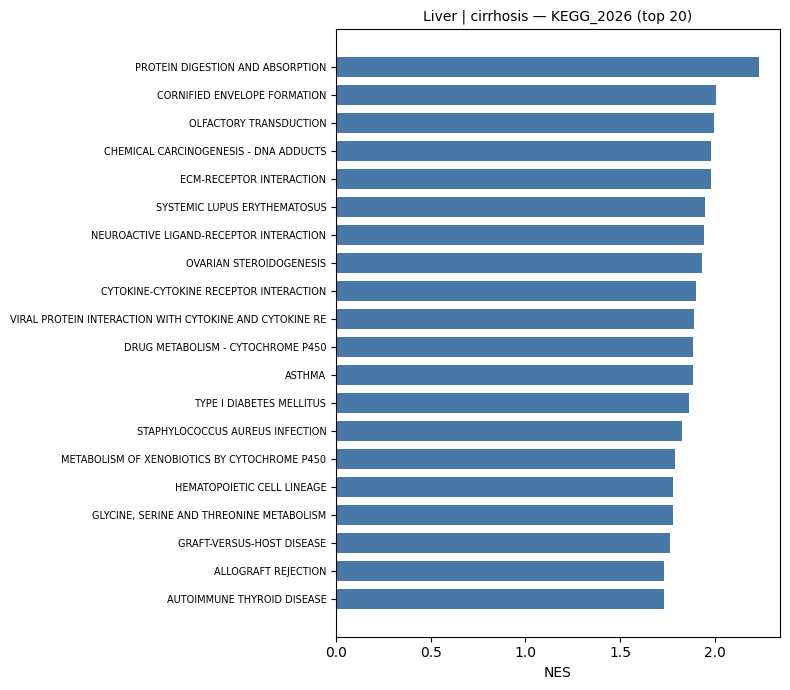

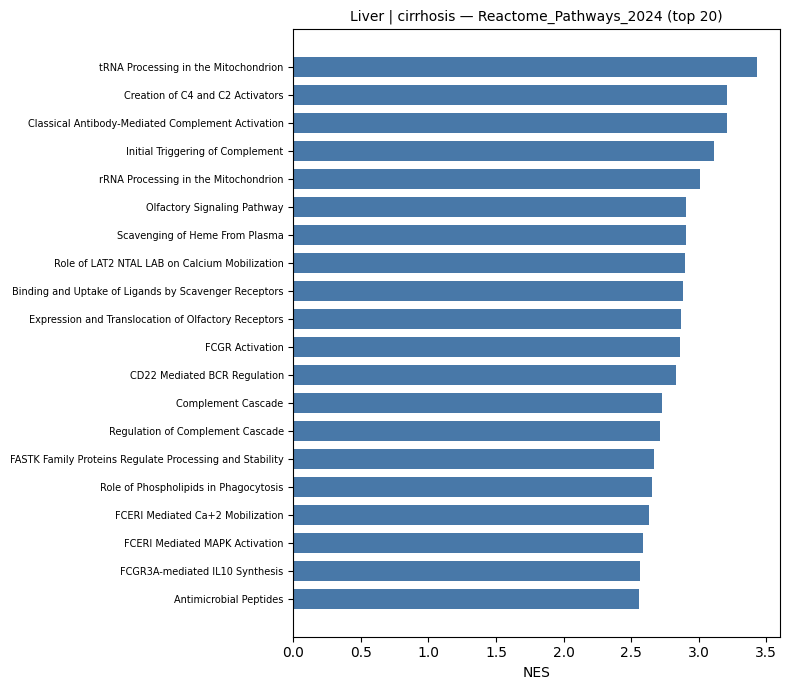

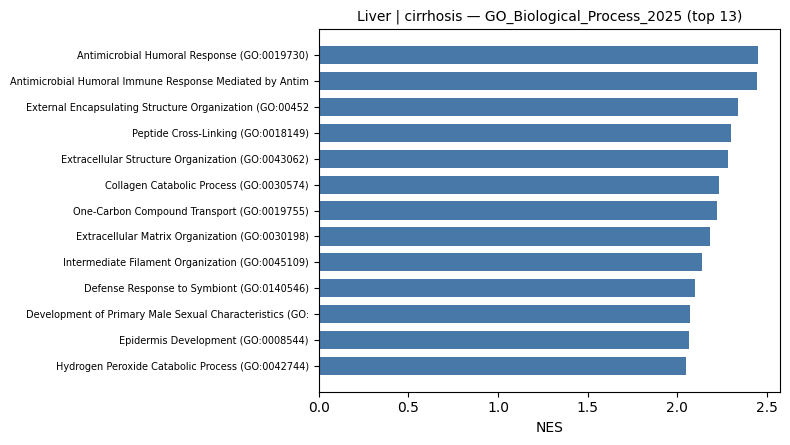

In [4]:
for lib in GENE_SET_LIBS:
    plot_top_pathways(demo_results[lib], "Liver | cirrhosis", lib)

---
## 12.2 — Scale to All 9 Pairs

Run GSEA prerank (all 20K genes, all 3 libraries) for every qualifying pair.

In [5]:
gsea_results = {}  # (tissue, category, lib) -> DataFrame

# Include Liver|cirrhosis results already computed
for lib in GENE_SET_LIBS:
    gsea_results[("Liver", "cirrhosis", lib)] = demo_results[lib]
print("[1/9] Liver | cirrhosis (already done)")

# Run remaining pairs
remaining = full_imp.groupby(["tissue", "category"]).filter(
    lambda g: not (g["tissue"].iloc[0] == "Liver" and g["category"].iloc[0] == "cirrhosis")
)

count = 1
for (tissue, category), grp in remaining.groupby(["tissue", "category"]):
    count += 1
    tag = f"{tissue} | {category}"
    print(f"\n[{count}/9] {tag}")
    ranked = build_ranked_list(grp)

    for lib in GENE_SET_LIBS:
        try:
            res = run_gsea_one_lib(ranked, lib, tag=tag)
            gsea_results[(tissue, category, lib)] = res
            sig = res[(res["FDR q-val"] < FDR_CUTOFF) & (res["NES"] > 0)]
            print(f"  {lib}: {len(sig)} positive-NES pathways")
        except Exception as e:
            print(f"  {lib}: ERROR — {e}")
            gsea_results[(tissue, category, lib)] = pd.DataFrame()

print(f"\nDone — {len(gsea_results)} results ({len(gsea_results)//3} pairs x 3 libraries).")

[1/9] Liver | cirrhosis (already done)

[2/9] Artery - Tibial | atherosis
  KEGG_2026: 3 positive-NES pathways
  Reactome_Pathways_2024: 71 positive-NES pathways
  GO_Biological_Process_2025: 13 positive-NES pathways

[3/9] Artery - Tibial | monckeberg
  KEGG_2026: 0 positive-NES pathways
  Reactome_Pathways_2024: 63 positive-NES pathways
  GO_Biological_Process_2025: 4 positive-NES pathways

[4/9] Breast - Mammary Tissue | atrophy
  KEGG_2026: 5 positive-NES pathways
  Reactome_Pathways_2024: 76 positive-NES pathways
  GO_Biological_Process_2025: 9 positive-NES pathways

[5/9] Liver | steatosis
  KEGG_2026: 12 positive-NES pathways
  Reactome_Pathways_2024: 84 positive-NES pathways
  GO_Biological_Process_2025: 7 positive-NES pathways

[6/9] Lung | congestion
  KEGG_2026: 0 positive-NES pathways
  Reactome_Pathways_2024: 67 positive-NES pathways
  GO_Biological_Process_2025: 5 positive-NES pathways

[7/9] Lung | edema
  KEGG_2026: 1 positive-NES pathways
  Reactome_Pathways_2024: 68 p

## 12.3 — Top 20 Pathways per Pair (by library)

Separate bar chart for each library × pair combination.

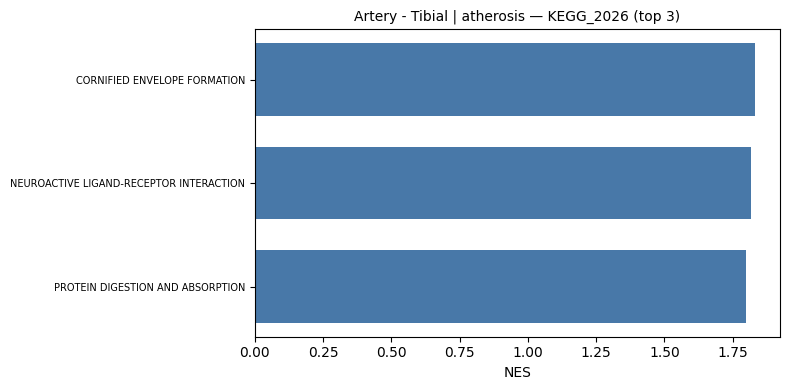

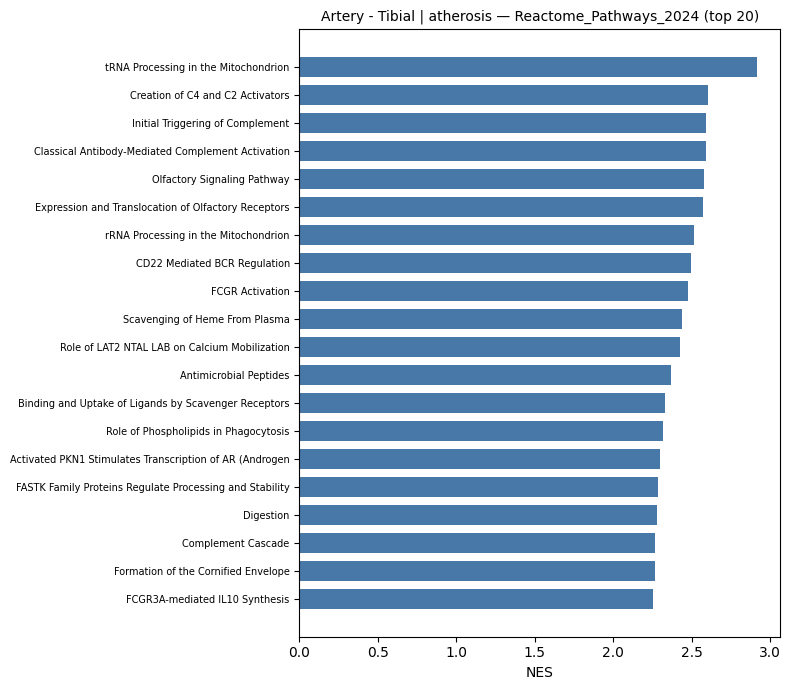

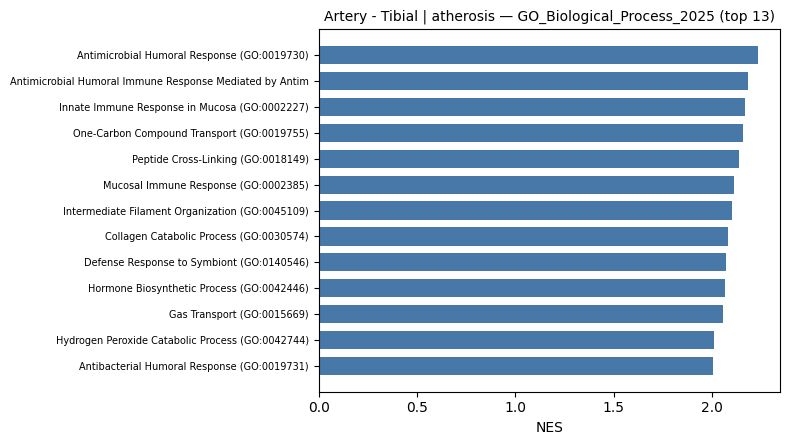

  KEGG_2026: no significant positive NES pathways


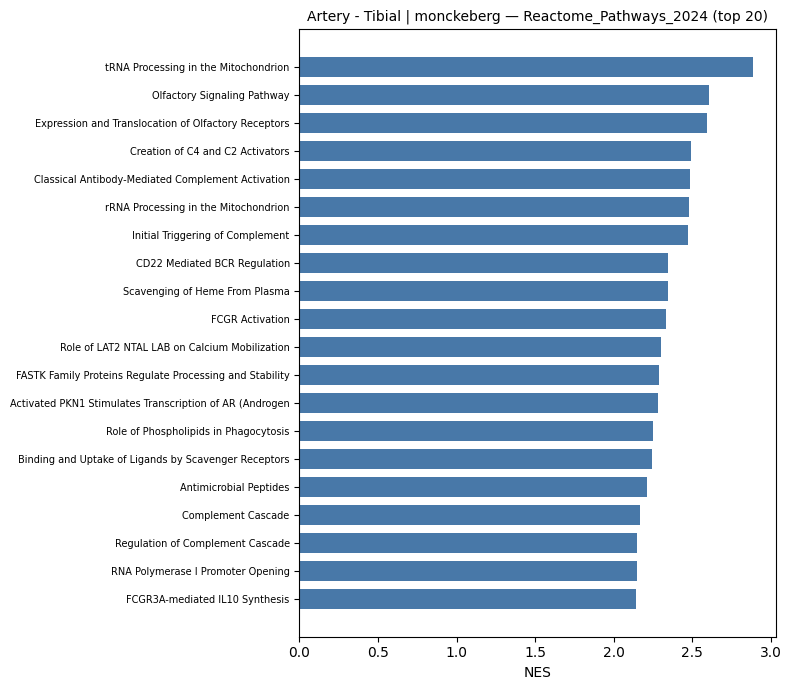

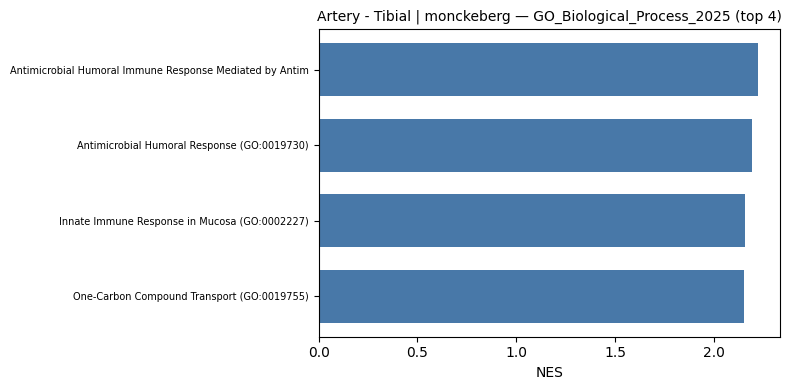

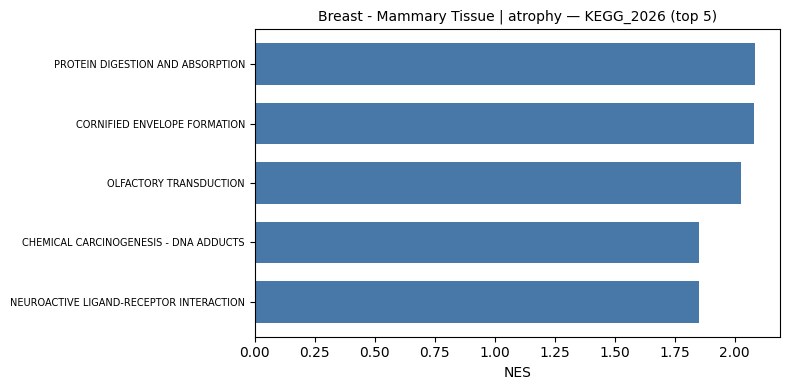

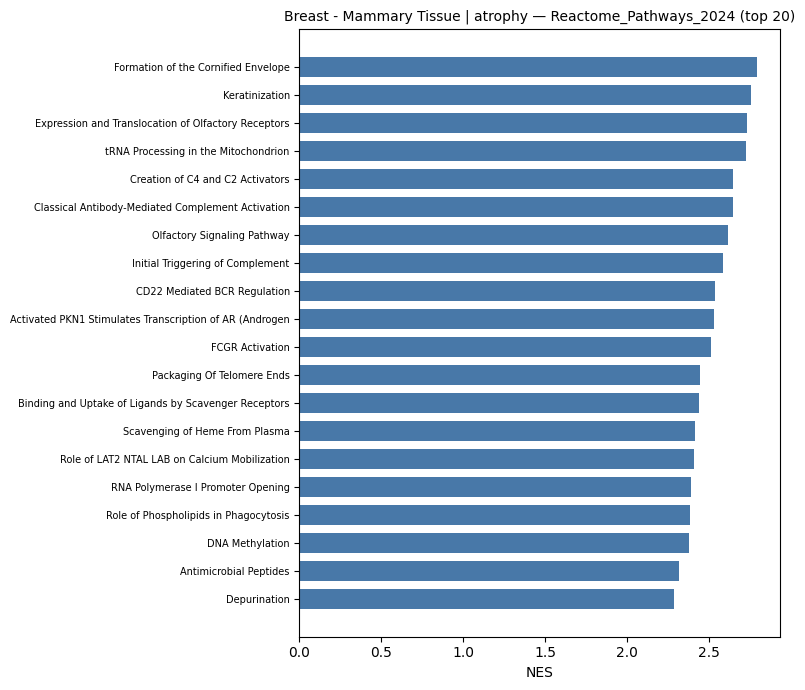

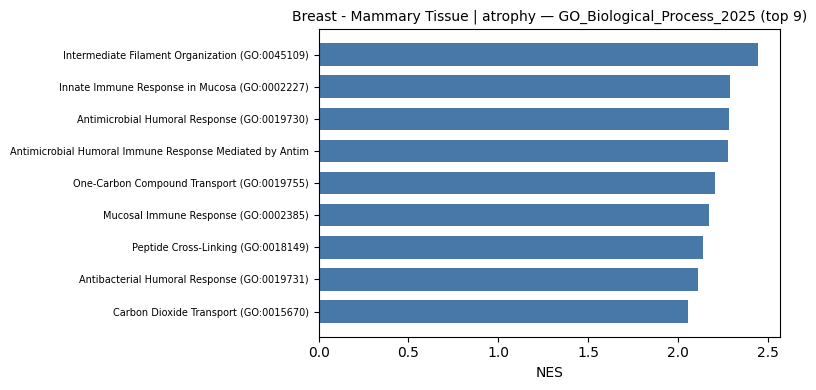

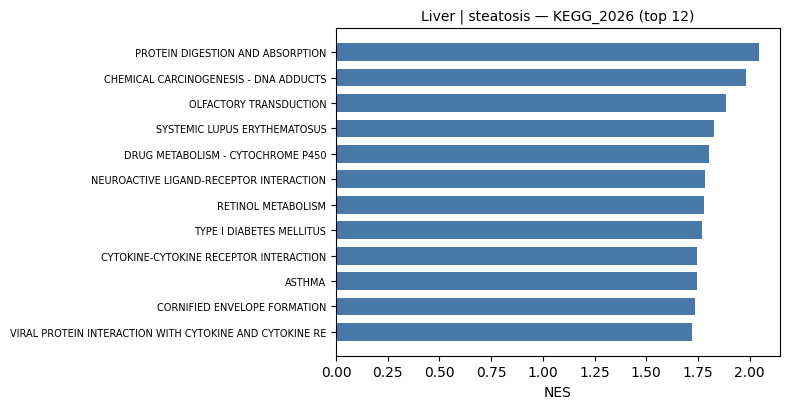

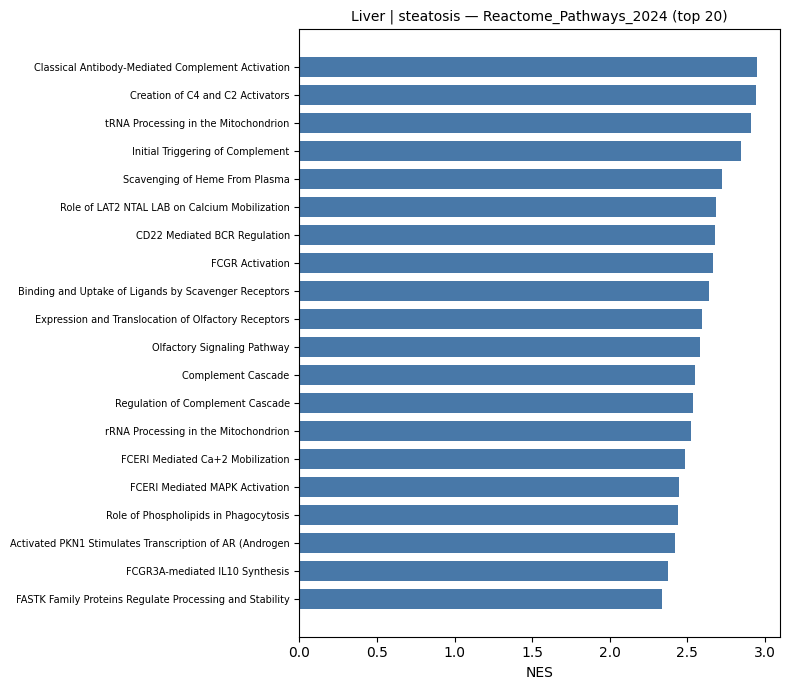

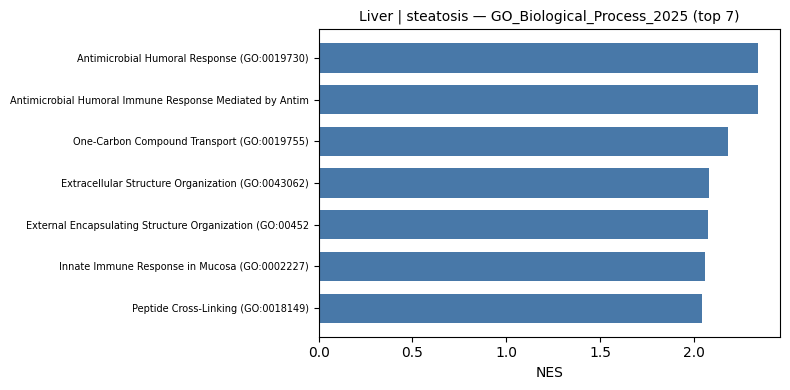

  KEGG_2026: no significant positive NES pathways


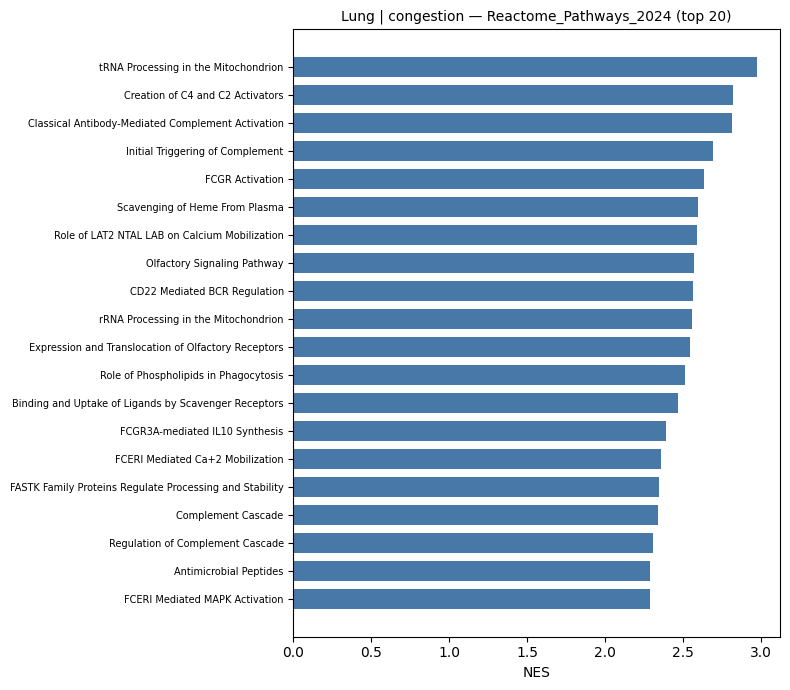

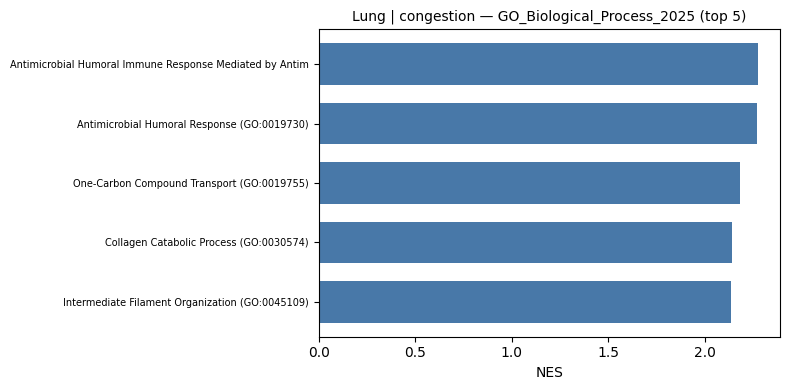

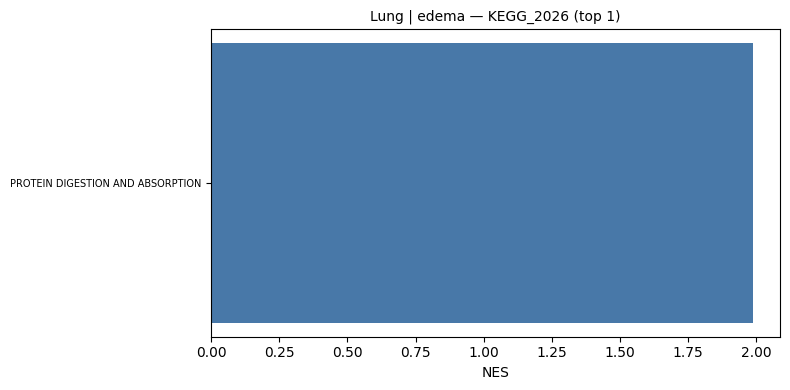

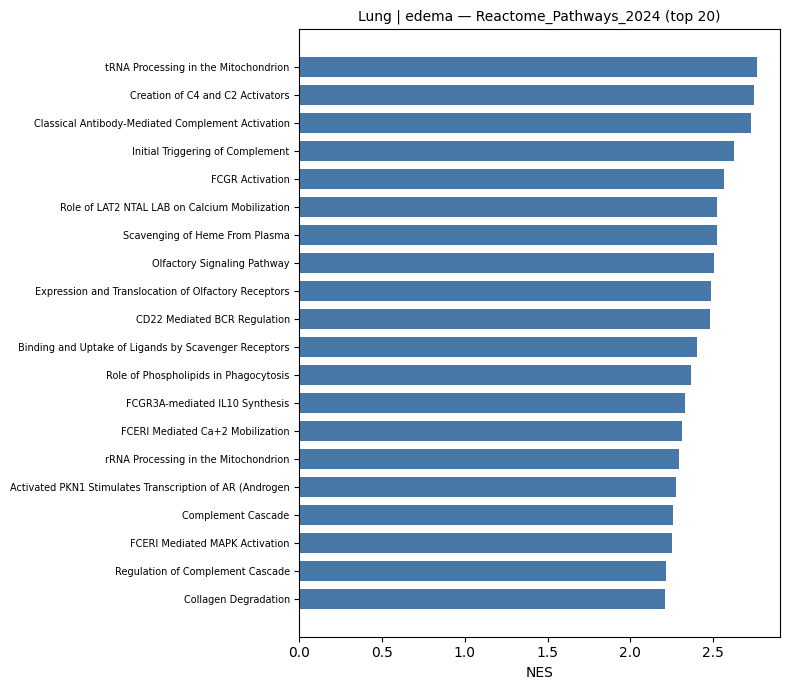

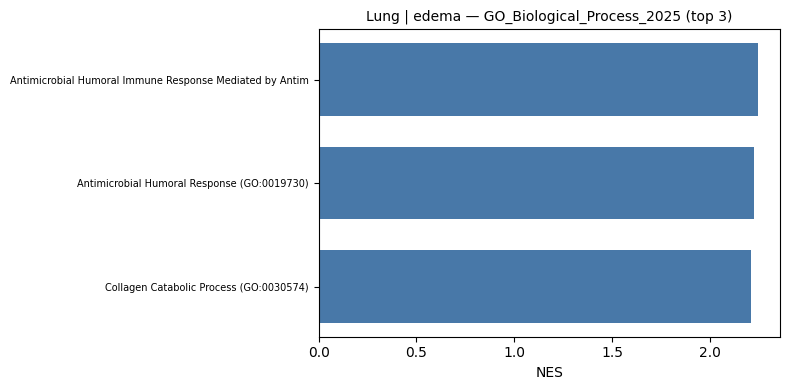

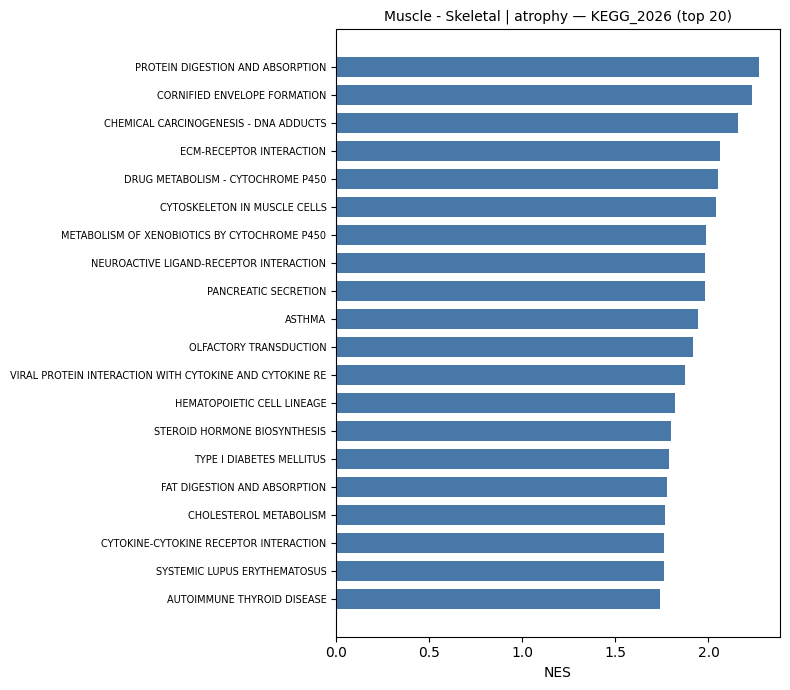

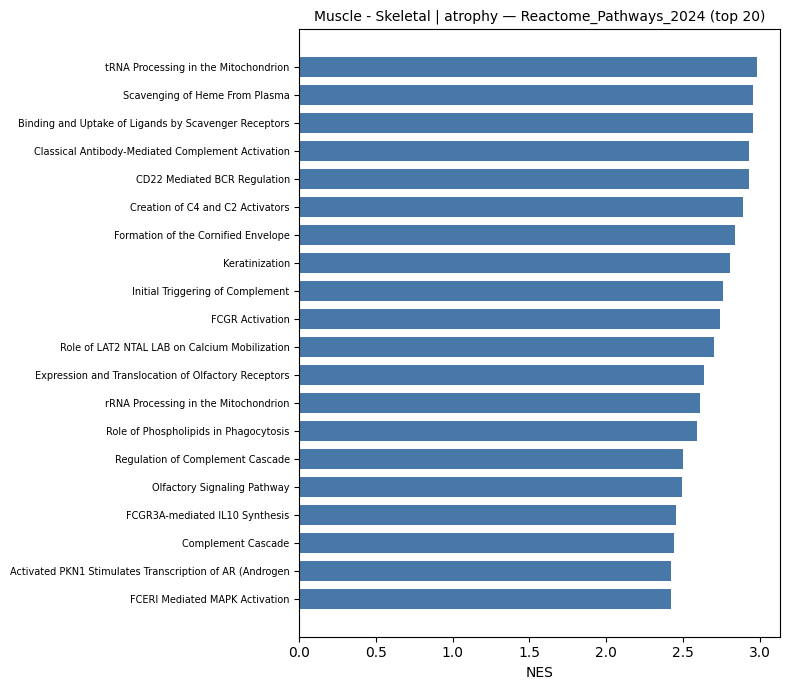

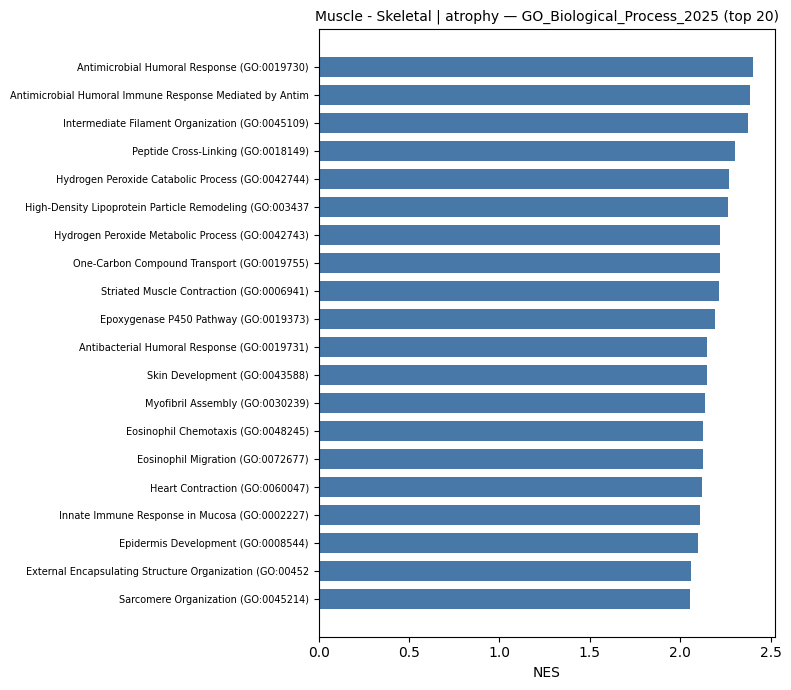

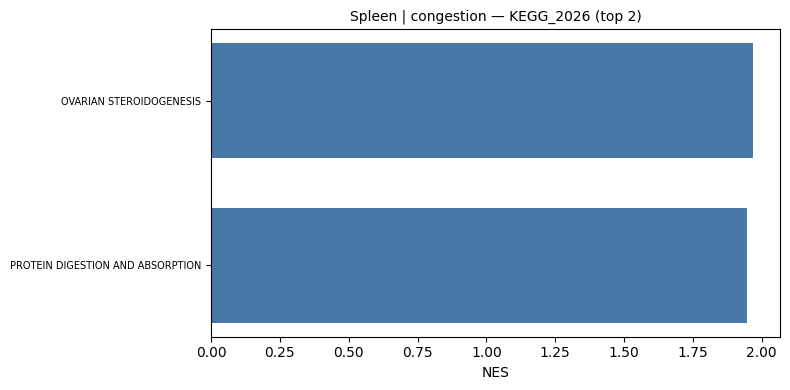

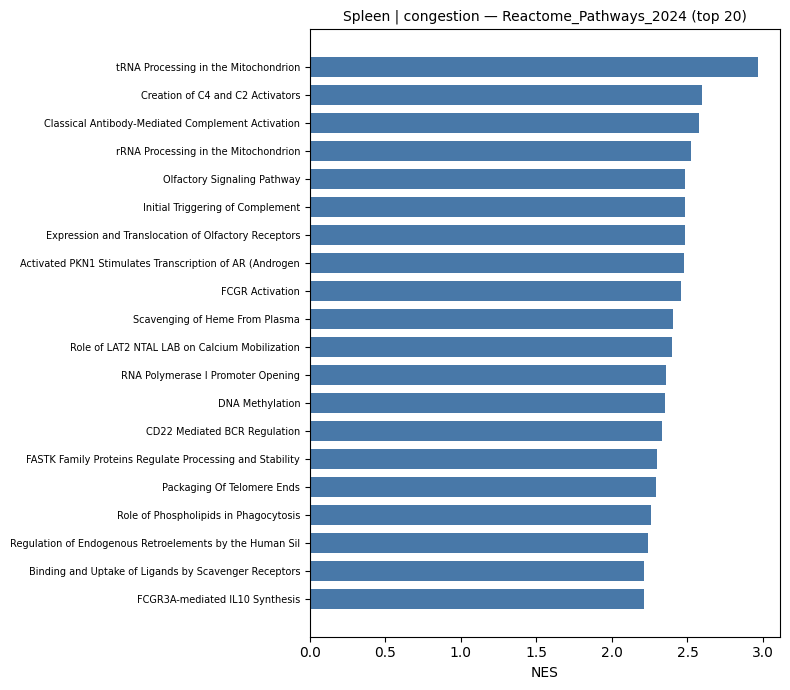

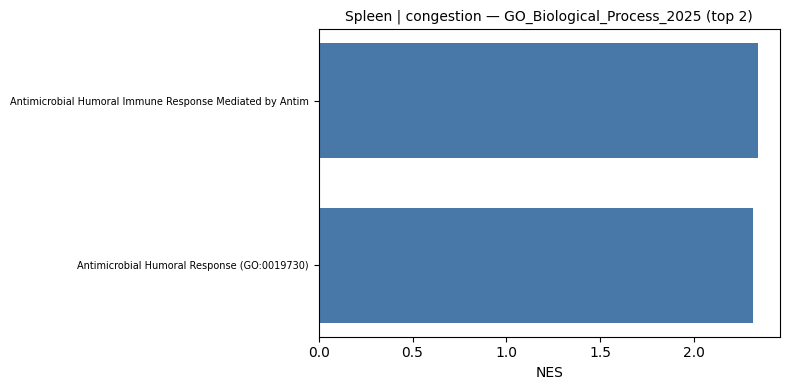

In [6]:
for (tissue, category, lib), res in gsea_results.items():
    if tissue == "Liver" and category == "cirrhosis":
        continue  # already plotted above
    if res.empty:
        continue
    tag = f"{tissue} | {category}"
    plot_top_pathways(res, tag, lib)

## 12.4 — Cross-Tissue Pathway Comparison

Which pathways are shared across pairs vs tissue-specific?  
Pathway × pair heatmap (per library).

In [7]:
# Collect all significant positive-NES pathways
all_pathways = []
for (tissue, category, lib), res in gsea_results.items():
    if res.empty:
        continue
    tag = f"{tissue} | {category}"
    sig = res[(res["FDR q-val"] < FDR_CUTOFF) & (res["NES"] > 0)]
    for _, r in sig.iterrows():
        term = r["Term"].replace(f"{lib}__", "")
        all_pathways.append({
            "tissue": tissue, "category": category, "label": tag,
            "library": lib, "pathway": term,
            "nes": r["NES"], "fdr": r["FDR q-val"],
        })

pathway_df = pd.DataFrame(all_pathways)
print(f"Total significant pathway hits (positive NES): {len(pathway_df)}")
print(f"Unique pathways: {pathway_df['pathway'].nunique()}")
print()

# Per-library summary
for lib in GENE_SET_LIBS:
    sub = pathway_df[pathway_df["library"] == lib]
    print(f"{lib}: {sub['pathway'].nunique()} unique pathways, {len(sub)} hits")

Total significant pathway hits (positive NES): 839
Unique pathways: 179

KEGG_2026: 27 unique pathways, 67 hits
Reactome_Pathways_2024: 120 unique pathways, 690 hits
GO_Biological_Process_2025: 32 unique pathways, 82 hits


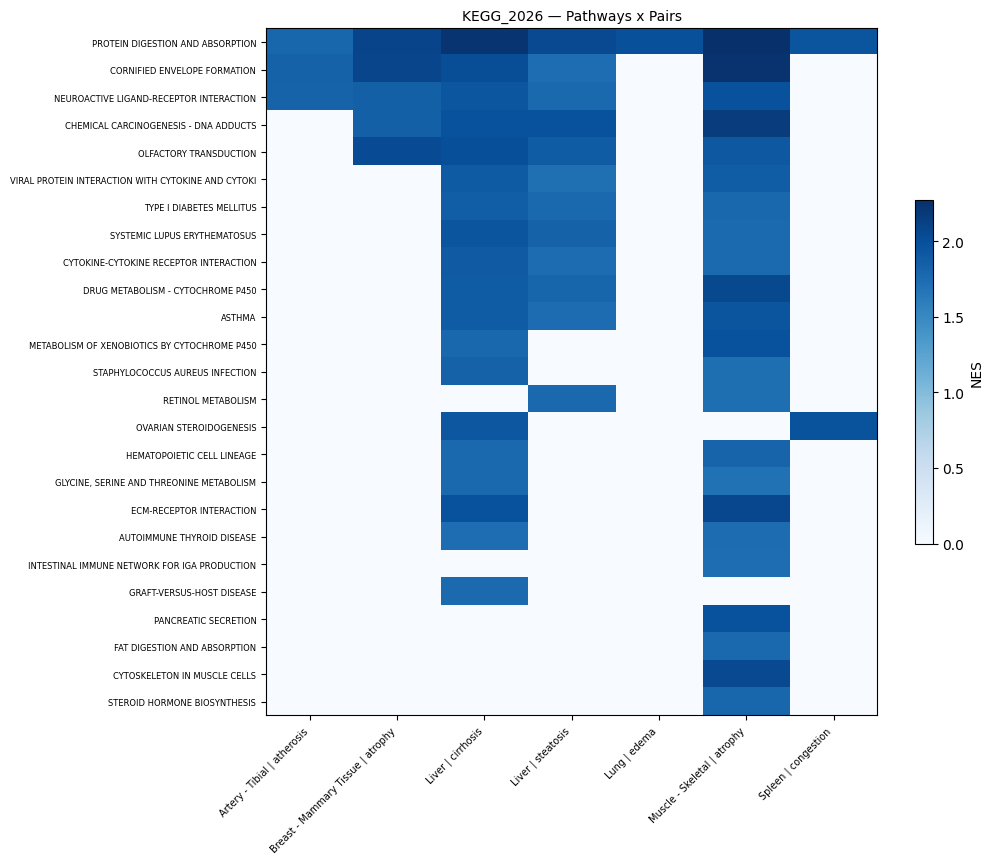

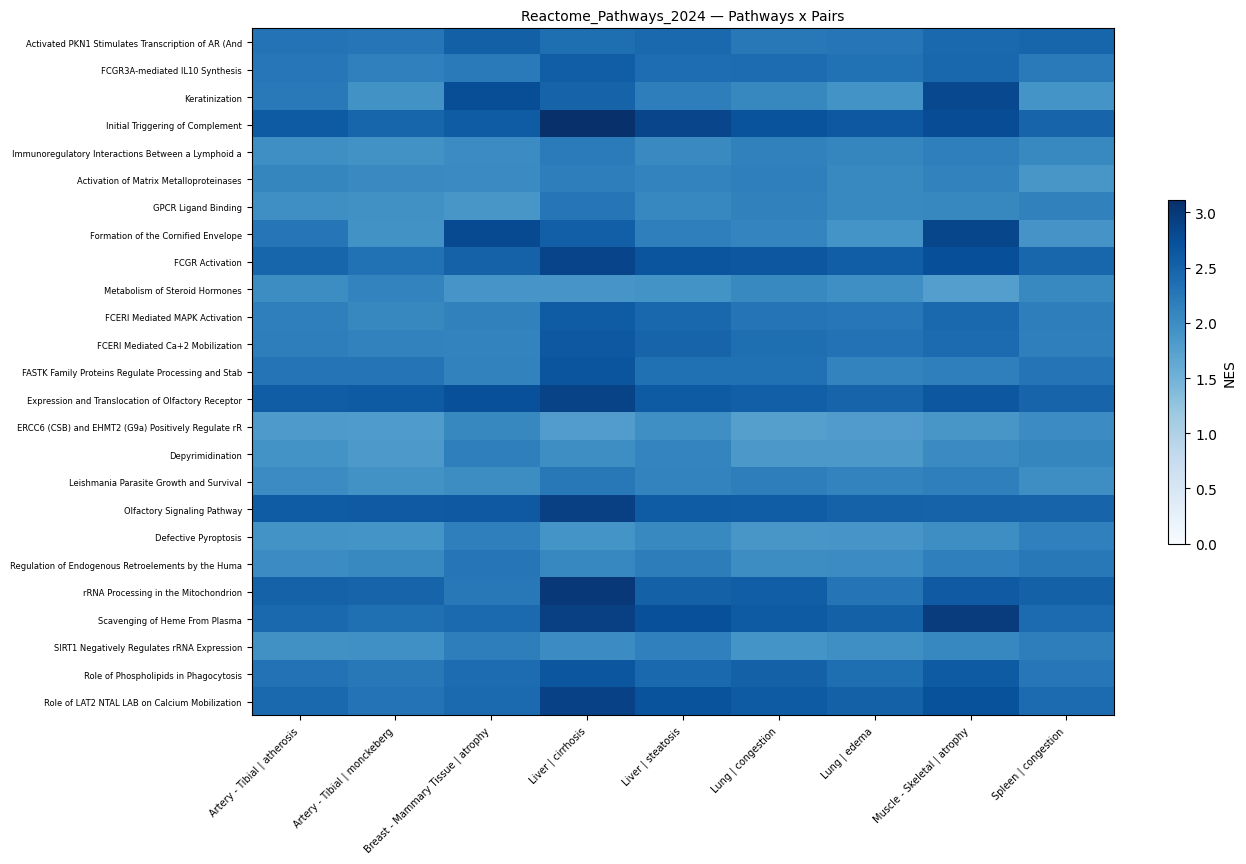

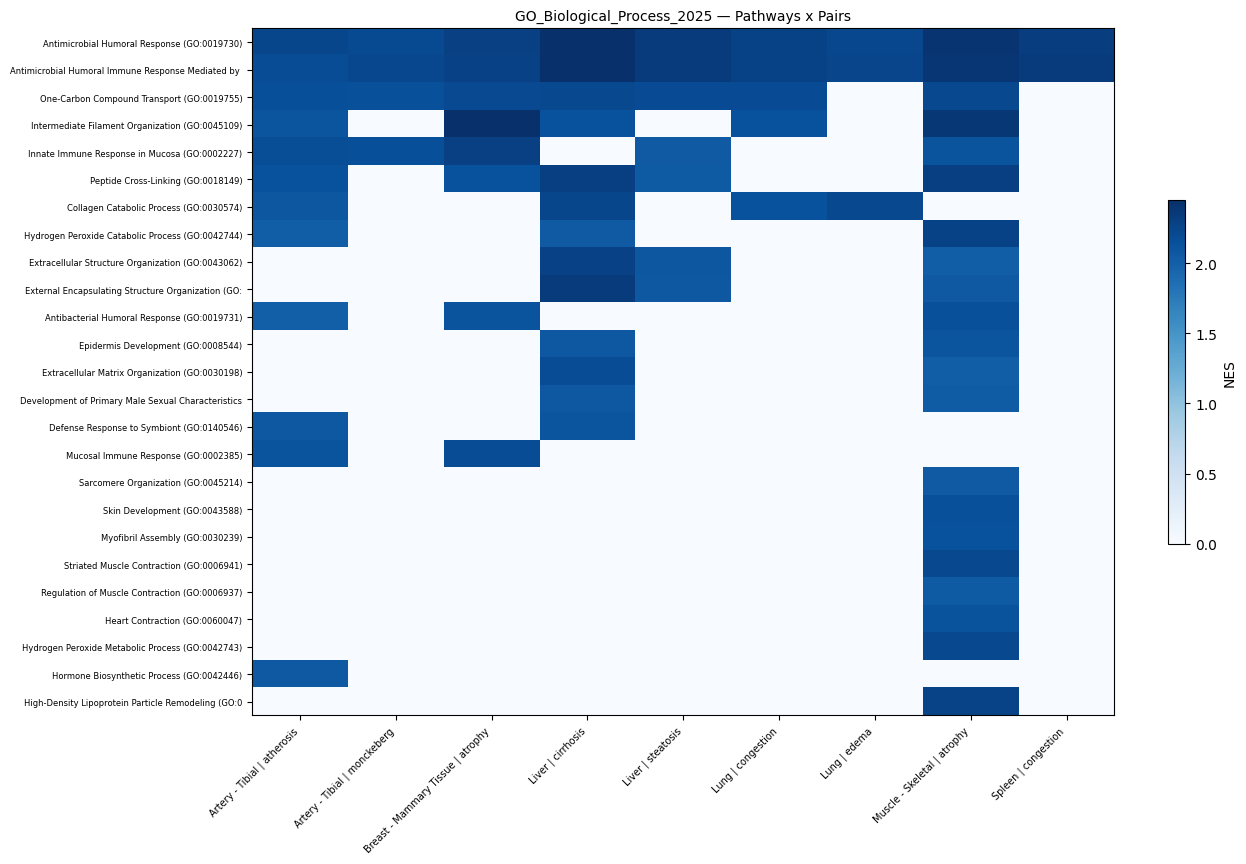

In [8]:
# Heatmap per library
for lib in GENE_SET_LIBS:
    sub = pathway_df[pathway_df["library"] == lib]
    if sub.empty:
        print(f"{lib}: no results")
        continue

    pivot = sub.pivot_table(index="pathway", columns="label", values="nes", aggfunc="max")
    pivot["n_pairs"] = pivot.notna().sum(axis=1)
    pivot = pivot.sort_values("n_pairs", ascending=False).drop(columns="n_pairs").head(25)
    heatmap_data = pivot.fillna(0)

    fig, ax = plt.subplots(figsize=(max(8, heatmap_data.shape[1] * 1.5),
                                     max(5, heatmap_data.shape[0] * 0.35)))
    im = ax.imshow(heatmap_data.values, aspect="auto", cmap="Blues", vmin=0)
    ax.set_xticks(range(heatmap_data.shape[1]))
    ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(heatmap_data.shape[0]))
    ax.set_yticklabels([t[:50] for t in heatmap_data.index], fontsize=6)
    cbar = fig.colorbar(im, ax=ax, shrink=0.5)
    cbar.set_label("NES")
    ax.set_title(f"{lib} — Pathways x Pairs", fontsize=10)
    fig.tight_layout()
    plt.show()

## 12.5 — Summary

In [9]:
if not pathway_df.empty:
    pathway_counts = pathway_df.groupby("pathway")["label"].nunique().sort_values(ascending=False)
    total_pw = len(pathway_counts)
    shared_pw = (pathway_counts >= 2).sum()
    specific_pw = (pathway_counts == 1).sum()

    print(f"Total unique enriched pathways: {total_pw}")
    print(f"Shared (>= 2 pairs):           {shared_pw} ({shared_pw/total_pw*100:.0f}%)")
    print(f"Tissue/pathology-specific:      {specific_pw} ({specific_pw/total_pw*100:.0f}%)")
    print()
    if shared_pw > specific_pw:
        print("\u2192 Majority shared — blood captures a systemic tissue-damage response.")
    else:
        print("\u2192 Majority tissue-specific — blood captures distinct signals per pathology.")

Total unique enriched pathways: 179
Shared (>= 2 pairs):           128 (72%)
Tissue/pathology-specific:      51 (28%)

→ Majority shared — blood captures a systemic tissue-damage response.


## 12.6 — Export (Q1)

In [10]:
if not pathway_df.empty:
    out_path = Config.TABLES_DIR / "gsea_pathway_enrichment.csv"
    pathway_df.to_csv(out_path, index=False)
    print(f"Saved {len(pathway_df)} rows to {out_path}")
    display(pathway_df.head(10))

Saved 839 rows to /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/tables/gsea_pathway_enrichment.csv


,tissue,category,label,library,pathway,nes,fdr
0,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,PROTEIN DIGESTION AND ABSORPTION,2.233343,0.001241
1,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,CORNIFIED ENVELOPE FORMATION,2.009477,0.021399
2,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,OLFACTORY TRANSDUCTION,1.997207,0.016954
3,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,CHEMICAL CARCINOGENESIS - DNA ADDUCTS,1.982890,0.014731
4,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,ECM-RECEPTOR INTERACTION,1.980784,0.012157
5,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,SYSTEMIC LUPUS ERYTHEMATOSUS,1.947963,0.014369
6,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,NEUROACTIVE LIGAND-RECEPTOR INTERACTION,1.940984,0.013114
7,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,OVARIAN STEROIDOGENESIS,1.930898,0.012405
8,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,CYTOKINE-CYTOKINE RECEPTOR INTERACTION,1.899903,0.016058
9,Liver,cirrhosis,Liver | cirrhosis,KEGG_2026,VIRAL PROTEIN INTERACTION WITH CYTOKINE AND CY...,1.890435,0.015817


---
---
# Part 2 — Q2: Do Pathologies in the Same Tissue Share Gene Signatures?

Three within-tissue comparisons:
- **Liver:** cirrhosis vs steatosis
- **Lung:** congestion vs edema
- **Artery - Tibial:** monckeberg vs atherosis

High overlap → tissue drives the signal. Low overlap → pathology-specific.

## 12.7 — Within-Tissue Gene Rank Correlation

In [11]:
WITHIN_TISSUE_PAIRS = [
    ("Liver", "cirrhosis", "steatosis"),
    ("Lung", "congestion", "edema"),
    ("Artery - Tibial", "monckeberg", "atherosis"),
]

for tissue, cat_a, cat_b in WITHIN_TISSUE_PAIRS:
    imp_a = full_imp[(full_imp["tissue"] == tissue) & (full_imp["category"] == cat_a)].set_index("gene_id")["importance"]
    imp_b = full_imp[(full_imp["tissue"] == tissue) & (full_imp["category"] == cat_b)].set_index("gene_id")["importance"]
    common = imp_a.index.intersection(imp_b.index)
    rho, pval = spearmanr(imp_a[common], imp_b[common])

    print(f"{tissue}: {cat_a} vs {cat_b}")
    print(f"  Spearman \u03c1 = {rho:.3f}  (p = {pval:.2e}, {len(common):,} genes)")
    print()

Liver: cirrhosis vs steatosis
  Spearman ρ = 0.990  (p = 0.00e+00, 20,000 genes)

Lung: congestion vs edema
  Spearman ρ = 0.993  (p = 0.00e+00, 20,000 genes)

Artery - Tibial: monckeberg vs atherosis
  Spearman ρ = 0.994  (p = 0.00e+00, 20,000 genes)



## 12.8 — Within-Tissue Top Gene Overlap

In [12]:
TOP_N_OVERLAP = 100

overlap_rows = []
for tissue, cat_a, cat_b in WITHIN_TISSUE_PAIRS:
    grp_a = full_imp[(full_imp["tissue"] == tissue) & (full_imp["category"] == cat_a)]
    grp_b = full_imp[(full_imp["tissue"] == tissue) & (full_imp["category"] == cat_b)]
    top_a = set(grp_a.nsmallest(TOP_N_OVERLAP, "rank")["gene_name"])
    top_b = set(grp_b.nsmallest(TOP_N_OVERLAP, "rank")["gene_name"])
    shared = top_a & top_b
    jaccard = len(shared) / len(top_a | top_b)

    overlap_rows.append({
        "tissue": tissue, "pathology_a": cat_a, "pathology_b": cat_b,
        "top_n": TOP_N_OVERLAP, "shared_genes": len(shared), "jaccard": jaccard,
    })
    print(f"{tissue}: {cat_a} vs {cat_b}")
    print(f"  Shared in top {TOP_N_OVERLAP}: {len(shared)} genes (Jaccard = {jaccard:.3f})")
    if shared:
        shared_names = sorted(shared - {g for g in shared if g.startswith('ENSG')})[:15]
        print(f"  Examples: {shared_names}")
    print()

display(pd.DataFrame(overlap_rows))

Liver: cirrhosis vs steatosis
  Shared in top 100: 65 genes (Jaccard = 0.481)
  Examples: ['ANO7L1', 'ARF4-AS1', 'CHGB', 'CORT', 'ESPN', 'ESRG', 'FAM210CP', 'GAL', 'GH1', 'GPX1P1', 'GSTA7P', 'HBG1', 'HBG2', 'HBZ', 'HDGFP1']

Lung: congestion vs edema
  Shared in top 100: 68 genes (Jaccard = 0.515)
  Examples: ['ANO7L1', 'ARF4-AS1', 'DCLRE1CP1', 'DEFA1', 'ESPN', 'FAM210CP', 'GAL', 'GCAT', 'GKN1', 'GPS2P1', 'GPX1P1', 'GSTA7P', 'HBG1', 'HBG2', 'HBZ']

Artery - Tibial: monckeberg vs atherosis
  Shared in top 100: 74 genes (Jaccard = 0.587)
  Examples: ['ACTG2', 'CDC42EP1', 'CHGB', 'ESRG', 'FAM210CP', 'FAM83A', 'GAL', 'GPS2P1', 'GPX1P1', 'GSTA7P', 'HBG1', 'HBG2', 'HBZ', 'HDGFP1', 'HOXB-AS3']



,tissue,pathology_a,pathology_b,top_n,shared_genes,jaccard
0,Liver,cirrhosis,steatosis,100,65,0.481481
1,Lung,congestion,edema,100,68,0.515152
2,Artery - Tibial,monckeberg,atherosis,100,74,0.587302


## 12.9 — Within-Tissue Pathway Overlap

In [13]:
for tissue, cat_a, cat_b in WITHIN_TISSUE_PAIRS:
    print(f"\n=== {tissue}: {cat_a} vs {cat_b} ===")
    for lib in GENE_SET_LIBS:
        res_a = gsea_results.get((tissue, cat_a, lib), pd.DataFrame())
        res_b = gsea_results.get((tissue, cat_b, lib), pd.DataFrame())
        if res_a.empty or res_b.empty:
            continue

        sig_a = set(res_a[(res_a["FDR q-val"] < FDR_CUTOFF) & (res_a["NES"] > 0)]["Term"])
        sig_b = set(res_b[(res_b["FDR q-val"] < FDR_CUTOFF) & (res_b["NES"] > 0)]["Term"])
        shared_pw = sig_a & sig_b
        only_a = sig_a - sig_b
        only_b = sig_b - sig_a
        jaccard_pw = len(shared_pw) / len(sig_a | sig_b) if (sig_a | sig_b) else 0

        print(f"  {lib}:")
        print(f"    {cat_a}: {len(sig_a)} | {cat_b}: {len(sig_b)} | Shared: {len(shared_pw)} (Jaccard={jaccard_pw:.3f})")
        print(f"    Unique to {cat_a}: {len(only_a)} | Unique to {cat_b}: {len(only_b)}")


=== Liver: cirrhosis vs steatosis ===
  KEGG_2026:
    cirrhosis: 20 | steatosis: 12 | Shared: 11 (Jaccard=0.524)
    Unique to cirrhosis: 9 | Unique to steatosis: 1
  Reactome_Pathways_2024:
    cirrhosis: 90 | steatosis: 84 | Shared: 77 (Jaccard=0.794)
    Unique to cirrhosis: 13 | Unique to steatosis: 7
  GO_Biological_Process_2025:
    cirrhosis: 13 | steatosis: 7 | Shared: 6 (Jaccard=0.429)
    Unique to cirrhosis: 7 | Unique to steatosis: 1

=== Lung: congestion vs edema ===
  KEGG_2026:
    congestion: 0 | edema: 1 | Shared: 0 (Jaccard=0.000)
    Unique to congestion: 0 | Unique to edema: 1
  Reactome_Pathways_2024:
    congestion: 67 | edema: 68 | Shared: 65 (Jaccard=0.929)
    Unique to congestion: 2 | Unique to edema: 3
  GO_Biological_Process_2025:
    congestion: 5 | edema: 3 | Shared: 3 (Jaccard=0.600)
    Unique to congestion: 2 | Unique to edema: 0

=== Artery - Tibial: monckeberg vs atherosis ===
  KEGG_2026:
    monckeberg: 0 | atherosis: 3 | Shared: 0 (Jaccard=0.000)

## 12.10 — Within-Tissue Scatter Plots

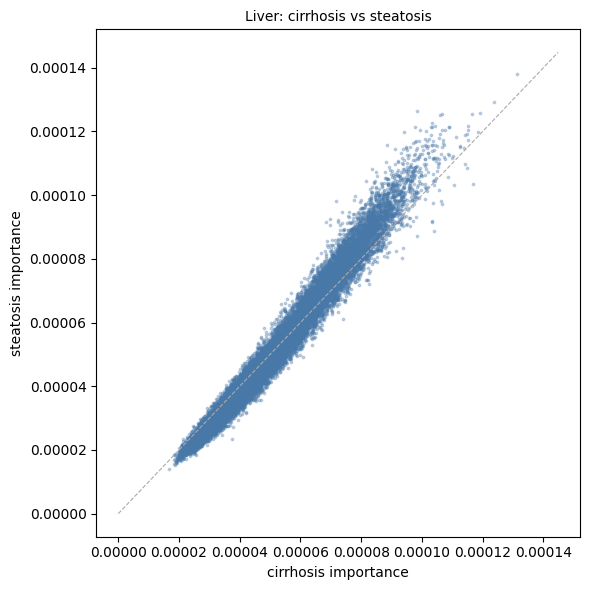

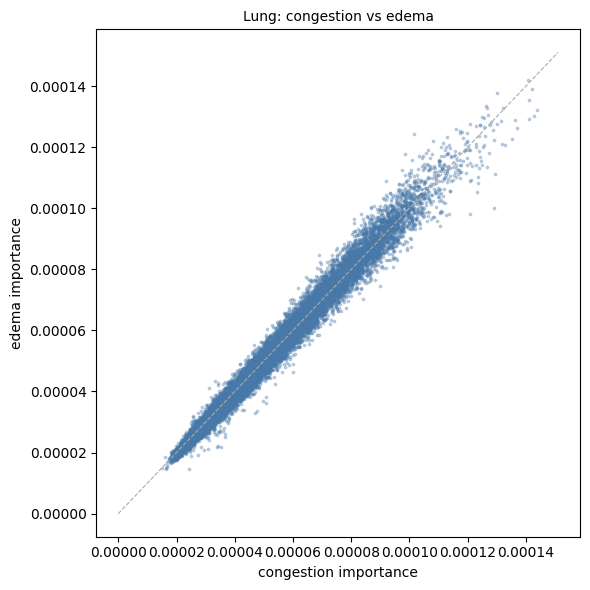

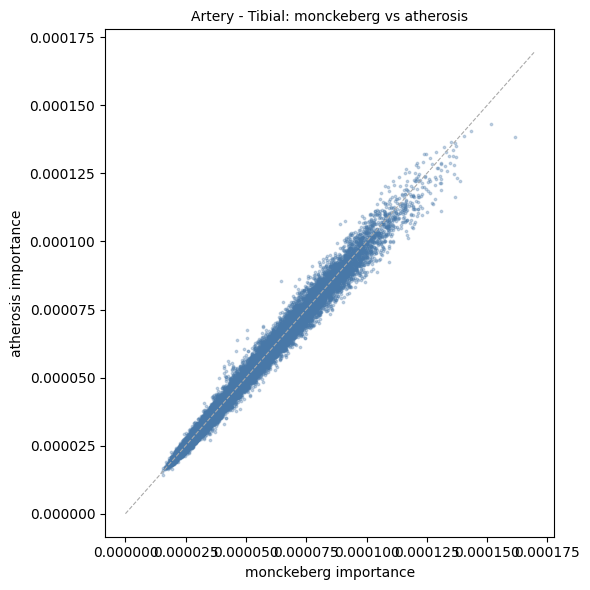

In [14]:
for tissue, cat_a, cat_b in WITHIN_TISSUE_PAIRS:
    imp_a = full_imp[(full_imp["tissue"] == tissue) & (full_imp["category"] == cat_a)].set_index("gene_id")["importance"]
    imp_b = full_imp[(full_imp["tissue"] == tissue) & (full_imp["category"] == cat_b)].set_index("gene_id")["importance"]
    common = imp_a.index.intersection(imp_b.index)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(imp_a[common], imp_b[common], s=3, alpha=0.3, color="#4878A8")
    lim = max(imp_a[common].max(), imp_b[common].max()) * 1.05
    ax.plot([0, lim], [0, lim], ls="--", color="#AAAAAA", lw=0.8)
    ax.set_xlabel(f"{cat_a} importance")
    ax.set_ylabel(f"{cat_b} importance")
    ax.set_title(f"{tissue}: {cat_a} vs {cat_b}", fontsize=10)
    fig.tight_layout()
    plt.show()